# Paper figures

## Setup — style, journal sizes, and shared loaders

In [1]:
import os, re, glob, json, yaml
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# --- required journal style -------------------------------------------------
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "lines.linewidth": 1.2,
        "lines.markersize": 4,
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        # --- journal-safe output + house style ------------------------------
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "axes.linewidth": 0.8,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "legend.frameon": False,
    }
)

# --- journal column widths (inches) ----------------------------------------
COL1 = 3.375  # single column  (8.6 cm)
COL2 = 6.75  # double column  (17.1 cm)

# --- one type scale, used verbatim by every normal figure ------------------
FS_LABEL = 8  # axis labels, sup-labels, subplot titles, colorbar labels
FS_TICK = 7  # tick labels, legends, panel letters, in-plot callouts
FS_SMALL = 6  # insets, dense in-panel text ("7 ns", fit legend, LxL, cbar ticks)

REF = 0.05  # 5% correlation-error target
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

# seaborn "colorblind" palette
COLORBLIND = [
    "#029E73",
    "#00008C",
    "#AD2E24",
    "#F58A07",
    "#F3B61F",
    "#620088",
    "#FBAFE4",
    "#949494",
    "#ECE133",
    "#56B4E9",
]

from src.utils import get_save_path

CONFIGS_PAPER = "configs"  # authoritative paper spec (make_paper_configs.py)
DATA_DIR = "./data"  # run outputs live under {DATA_DIR}/tvmc/<experiment>/
EIGH_DIR = "./data/eigh"  # benchmark_eigh.py outputs (NOT moved to data_old)

# --- shared experiment constants (single source of truth for every cell) ----
S = 1.0  # anneal snapshot at which eps_c is judged
STAGE = 0  # RK45 stage whose epsilon_squared is the TDVP residual
EXPERIMENTS = {7: "final_7", 20: "final_20"}  # t_a (ns) -> experiment folder
RANKS = [1, 2, 3, 4]  # ansatz ranks R
COV_MIN, S_MAX_MIN = 0.98, 0.98  # data-quality gates, see _tdvp_residual
# TOPO_ORDER is the left-to-right order of fig_final; TOPOS is the 2x2 panel
# order of the residual/steps blocks. Same four topologies, different layouts.
TOPO_ORDER = ["diamond", "2d", "biclique", "3ddimer"]
TOPOS = ["2d", "3ddimer", "biclique", "diamond"]
# TOPO_LABEL maps the folder prefix to its display name.
TOPO_LABEL = {"diamond": "Diamond", "2d": "2D Cylinder",
              "biclique": "Biclique", "3ddimer": "3D dimer"}
TOPO_MARKER = {"2d": "o", "3ddimer": "s", "biclique": "p", "diamond": "D"}
rank_col = {r: COLORBLIND[i] for i, r in enumerate(RANKS)}


def load_corr_errors(npz_path):
    """(eps_c, eps_c errorbar) vs MPS and vs QPU from a corrs_n*_t*.npz.

    Returns (err_mps, err_mps_std, err_qpu, err_qpu_std). The *_std entries are
    the propagated Monte-Carlo errorbars on eps_c written by verify_tvmc; they are
    nan for legacy files saved before errorbars were stored."""
    d = np.load(npz_path)
    err_mps = (
        float(d["correlation_error_mps"])
        if "correlation_error_mps" in d
        else float(d["correlation_error"])
    )  # legacy: MPS only
    err_qpu = (
        float(d["correlation_error_qpu"]) if "correlation_error_qpu" in d else np.nan
    )
    err_mps_std = (
        float(d["correlation_error_mps_std"])
        if "correlation_error_mps_std" in d
        else np.nan
    )
    err_qpu_std = (
        float(d["correlation_error_qpu_std"])
        if "correlation_error_qpu_std" in d
        else np.nan
    )
    return err_mps, err_mps_std, err_qpu, err_qpu_std


def _nsites(path):
    """True site count from a corrs file: it stores all N(N-1)/2 unique pairs, so
    N is recovered from len(correlations) rather than from the shape box."""
    L = len(np.load(path)["correlations"])
    return int(round((1 + np.sqrt(1 + 8 * L)) / 2))


def _nsites_shape(save_path):
    """N from any corrs file in a run folder, or nan if the folder has none."""
    f = glob.glob(os.path.join(save_path, "corrs_n*_t*.npz"))
    return _nsites(f[0]) if f else np.nan


def _yerr(arr):
    """Errorbar magnitudes for plt.errorbar: nan/inf (missing errorbars, e.g.
    legacy corrs npz) -> 0 so those points draw no bar instead of raising."""
    a = np.asarray(arr, float)
    return np.where(np.isfinite(a), a, 0.0)


def paper_configs(experiment):
    """Yield (yaml_path, cfg) for every config under configs_paper/<experiment>/."""
    for p in sorted(glob.glob(os.path.join(CONFIGS_PAPER, experiment, "*.yaml"))):
        with open(p) as fh:
            yield p, yaml.safe_load(fh)


def find_paper_run(experiment, match=None, data_dir=DATA_DIR):
    """[(cfg, save_path), ...] for configs of <experiment> matching `match`.

    `match`: {config_key: value | (allowed,) | predicate}. `save_path` is the
    hash-exact folder for that config (so it resolves the real paper run once it
    is generated from these exact YAMLs). Missing folders are reported by the cell.
    """
    out, seen = [], set()
    for _, cfg in paper_configs(experiment):
        if match:
            ok = True
            for k, v in match.items():
                cv = cfg.get(k)
                if callable(v):
                    ok &= bool(v(cv))
                elif isinstance(v, (list, tuple)) and not isinstance(cv, (list, tuple)):
                    ok &= cv in v
                else:
                    ok &= cv == v
            if not ok:
                continue
        c = dict(cfg)
        c["data_dir"] = data_dir
        
        sp = get_save_path(c, create=False)
        if sp in seen:  # identical config hash -> same run (e.g. redundant
            continue    # _rcond_smooth1em12 configs that duplicate the default)
        seen.add(sp)
        out.append((c, sp))
    return out


def load_log(save_path):
    """A run's log.json (serialized nk RuntimeLog) or None if absent."""
    p = os.path.join(save_path, "log.json")
    if not os.path.exists(p):
        return None
    with open(p) as fh:
        return json.load(fh)


def series(log, key):
    """(iters, values) for a top-level log key (History dict or plain list)."""
    v = log[key]
    if isinstance(v, dict) and "value" in v:
        return np.asarray(v["iters"], float), np.asarray(v["value"], float)
    return np.arange(len(v), dtype=float), np.asarray(v, float)


def to_s(log, iters):
    """Map logged step indices to the anneal parameter s (via log['t'])."""
    ti, tv = series(log, "t")
    return np.interp(np.asarray(iters, float), ti, tv)


def generator_field(log, field="R_hat"):
    """(iters, values) for a sub-field of the Generator stats (R_hat, Mean, ...)."""
    g = log["Generator"]
    it = np.asarray(g["iters"], float)
    v = g[field]
    if isinstance(v, dict) and "value" in v:
        v = v["value"]
    return it, np.asarray(v, float)


def corr_files(save_path, s):
    """{n_samples: path} for corrs_n*_t{s:1.3f}.npz in a run folder."""
    out = {}
    for f in glob.glob(os.path.join(save_path, f"corrs_n*_t{s:1.3f}.npz")):
        m = re.search(r"corrs_n(\d+)_t", os.path.basename(f))
        if m:
            out[int(m.group(1))] = f
    return out


def best_corr_error(save_path, s, ref="mps", with_err=False):
    """eps_c (and, if with_err, its MC errorbar) at the largest available eval
    N_s for snapshot s. Returns nan (or (nan, nan) when with_err) if none."""
    cf = corr_files(save_path, s)
    if not cf:
        return (np.nan, np.nan) if with_err else np.nan
    em, em_s, eq, eq_s = load_corr_errors(cf[max(cf)])
    e, es = (em, em_s) if ref == "mps" else (eq, eq_s)
    return (e, es) if with_err else e


def scan_experiment_corrs(experiment, data_dir=DATA_DIR):
    """Path-parsed inventory of every corrs_*.npz under data/tvmc/<experiment>/.

    ``experiment`` may be a single name or an iterable of names (results merged).
    Hash-agnostic (topology/shape/instance/t_a come from the path), so it also
    picks up legacy runs whose config hash differs from the current paper YAMLs.
    Records: {experiment, topology, shape, instance, t_a, n_samples, s, eps_c_mps,
    eps_c_mps_std, eps_c_qpu, eps_c_qpu_std, path}.
    """
    experiments = [experiment] if isinstance(experiment, str) else list(experiment)
    recs = []
    for exp in experiments:
        base = os.path.join(data_dir, "tvmc", exp)
        for f in glob.glob(
            os.path.join(base, "*", "instance_*", "**", "corrs_n*_t*.npz"),
            recursive=True,
        ):
            rel = os.path.relpath(f, base).split(os.sep)
            topo, _, shp = rel[0].partition("_")  # diamond_5x5x8 -> diamond, 5x5x8
            inst = int(next(p for p in rel if p.startswith("instance_")).split("_")[1])
            t_a = float(next(p for p in rel if p.startswith("t_a_"))[len("t_a_"):])
            # rank lives in the model-string path segment (jastrow_o24 -> R=1,
            # jastrow_o24_r3 -> R=3); rbm runs have no _r tag either.
            model_seg = next((p for p in rel if p.startswith(("jastrow", "rbm"))), "")
            mr = re.search(r"_r(\d+)", model_seg)
            rank = int(mr.group(1)) if mr else 1
            m = re.search(r"corrs_n(\d+)_t([\d.]+)\.npz", os.path.basename(f))
            em, em_s, eq, eq_s = load_corr_errors(f)
            recs.append(
                dict(
                    experiment=exp,
                    topology=topo,
                    shape=shp,
                    instance=inst,
                    t_a=t_a,
                    rank=rank,
                    n_samples=int(m.group(1)),
                    s=float(m.group(2)),
                    eps_c_mps=em,
                    eps_c_mps_std=em_s,
                    eps_c_qpu=eq,
                    eps_c_qpu_std=eq_s,
                    path=f,
                )
            )
    return recs

def load_eigh_runs():
    """{(mode, n_dev): sorted-by-n_params list of records} from data/eigh/**/solve_*_np*.npz.

    One series per (mode, device count), so every ndev_<k> case on disk is plotted
    separately (single is always ndev_1; sharded may span several device counts).
    Recursive glob also picks up any legacy flat data/eigh/solve_*.npz files."""
    runs = {}
    for f in sorted(
        glob.glob(os.path.join(EIGH_DIR, "**", "solve_*_np*.npz"), recursive=True)
    ):
        d = np.load(f, allow_pickle=True)
        rec = {k: (d[k].item() if d[k].ndim == 0 else d[k]) for k in d.files}
        runs.setdefault((rec["mode"], int(rec["n_devices"])), []).append(rec)
    for key in runs:
        runs[key].sort(key=lambda r: r["n_params"])
    return runs


def _log_walltime(logpath):
    """(walltime_seconds, n_steps, done) from a NetKet log.json."""
    with open(logpath) as f:
        log = json.load(f)
    total = log.get("time/total")
    if total is None:
        return None, None, None
    t = log.get("t", {})
    done = bool(t) and bool(np.isclose(t["value"][-1], 1.0, atol=1e-2))
    values = total["value"]
    return sum(values), len(values), done


def scan_all_walltimes(experiment, data_dir=DATA_DIR):
    """One record per log.json under the experiment(s); path-parsed like
    scan_experiment_steps (topology / shape / instance / t_a / rank)."""
    experiments = [experiment] if isinstance(experiment, str) else list(experiment)
    recs = []
    for exp in experiments:
        base = os.path.join(data_dir, "tvmc", exp)
        for f in glob.glob(os.path.join(base, "*", "instance_*", "**", "log.json"),
                           recursive=True):
            walltime, n_steps, done = _log_walltime(f)
            if walltime is None:
                continue
            rel = os.path.relpath(f, base).split(os.sep)
            topo, _, shp = rel[0].partition("_")
            inst = int(next(p for p in rel if p.startswith("instance_")).split("_")[1])
            t_a = float(next(p for p in rel if p.startswith("t_a_"))[len("t_a_"):])
            model_seg = next((p for p in rel if p.startswith(("jastrow", "rbm"))), "")
            mr = re.search(r"_r(\d+)", model_seg)
            recs.append({"experiment": exp, "path": f, "topology": topo, "shape": shp,
                         "instance": inst, "t_a": t_a,
                         "rank": int(mr.group(1)) if mr else 1,
                         "walltime": walltime, "n_steps": n_steps, "done": done})
    return recs


def _hms(seconds):
    h, rem = divmod(int(seconds), 3600)
    m, s = divmod(rem, 60)
    return f"{h:>4}:{m:02d}:{s:02d}"


def _run_dirs(experiment, topology, shape, instance, t_a, data_dir=DATA_DIR):
    """{rank: save_path} for the runs of one (topology, shape, instance, t_a).

    Path-parsed like scan_experiment_logs (rank lives in the model segment:
    jastrow_o24 -> R=1, jastrow_o24_r3 -> R=3), so it is hash-agnostic."""
    base = os.path.join(data_dir, "tvmc", experiment,
                        f"{topology}_{shape}", f"instance_{instance}", f"t_a_{t_a:g}")
    out = {}
    for f in glob.glob(os.path.join(base, "**", "log.json"), recursive=True):
        seg = next((p for p in os.path.relpath(f, base).split(os.sep)
                    if p.startswith(("jastrow", "rbm"))), "")
        mr = re.search(r"_r(\d+)", seg)
        out[int(mr.group(1)) if mr else 1] = os.path.dirname(f)
    return out



## Final runs: $\epsilon_c < 5\%$ for all topologies

$\epsilon_c$ for every topology/shape and ansatz rank $R\in\{1,2,3,4\}$, split into $t_a=7$ ns (left) and
$t_a=20$ ns (right) and colored by rank, with the 5% reference line. 

Where a (shape, rank) has several disorder instances the point is their **median** and the bar
their **min--max spread**.

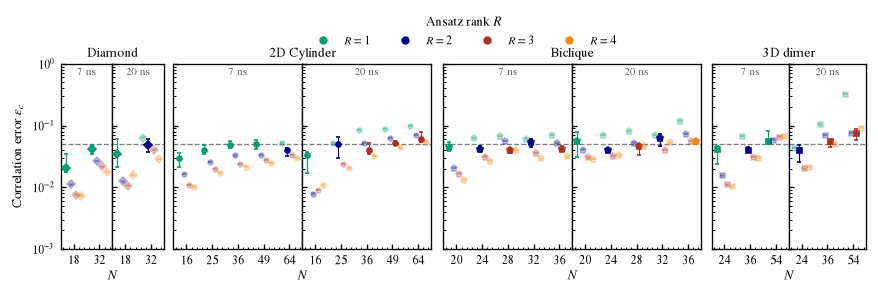

In [2]:
# S, EXPERIMENTS, RANKS, rank_col and the TOPO_* tables come from the setup cell.
recs = [r for r in scan_experiment_corrs(list(EXPERIMENTS.values()))
        if abs(r["s"] - S) < 1e-6]
# largest eval N_s per (topology, shape, instance, t_a, rank)
best = {}
for r in recs:
    k = (r["topology"], r["shape"], r["instance"], r["t_a"], r["rank"])
    if k not in best or r["n_samples"] > best[k]["n_samples"]:
        best[k] = r

# shapes per topology (union over t_a), sorted -> shared x within a pair
topo_shapes = {t: sorted({r["shape"] for r in best.values() if r["topology"] == t})
               for t in TOPO_ORDER}
topos = [t for t in TOPO_ORDER if topo_shapes[t]]   # drop wholly-absent topologies
# true site count N comes from the data, not the shape box (see _nsites);
# one representative path per (topology, shape) -> N
nsites = {(r["topology"], r["shape"]): _nsites(r["path"])
          for r in best.values()}

span = 0.30  # rank x-offset within a shape
off = {r: (0.0 if len(RANKS) == 1 else np.linspace(-span, span, len(RANKS))[i])
       for i, r in enumerate(RANKS)}

fig = plt.figure(figsize=(COL2, COL2 * 0.36))
subfigs = fig.subfigures(1, len(topos), wspace=0.015,
                         width_ratios=[len(topo_shapes[t]) for t in topos])
if len(topos) == 1:
    subfigs = [subfigs]

for ti, (topo, subfig) in enumerate(zip(topos, subfigs)):
    shapes = topo_shapes[topo]
    # the two t_a panels are glued: shared x (same shapes) and y, no gap between
    axpair = subfig.subplots(1, 2, sharey=True, sharex=True,
                             gridspec_kw={"wspace": 0})
    for ax, (ta, exp) in zip(axpair, EXPERIMENTS.items()):
        sub = [r for r in best.values()
               if r["t_a"] == ta and r["topology"] == topo]
        for x, shp in enumerate(shapes):
            for rk in RANKS:
                rs = [r for r in sub if r["shape"] == shp and r["rank"] == rk]
                if not rs:
                    continue
                es = np.array([r["eps_c_mps"] for r in rs])
                eb = np.array([r["eps_c_mps_std"] for r in rs])
                xc = x + off[rk]
                if es.size > 1:
                    y = float(np.median(es))
                    yerr = [[y - es.min()], [es.max() - y]]
                    alpha=1.
                else:
                    y, yerr = float(es[0]), _yerr(eb).reshape(1, 1)
                    alpha=0.25
                ax.errorbar([xc], [y], yerr=yerr, marker=TOPO_MARKER[topo], ms=4 if TOPO_MARKER[topo]=="p" else 3,
                            color=rank_col[rk], alpha=alpha, ecolor=rank_col[rk],
                            elinewidth=0.7, capsize=1.2, ls="none", zorder=3)
        if not sub:
            ax.text(0.5, 0.5, "\u2014", ha="center", va="center",
                    transform=ax.transAxes, color="0.6")
        ax.axhline(REF, color="0.5", ls="--", lw=0.8)
        ax.set_yscale("log"); ax.set_ylim(1e-3, 1.0)
        ax.set_xlim(-0.5, len(shapes) - 0.5)
        ax.set_xticks(range(len(shapes)))
        ax.set_xticklabels([nsites[(topo, s)] for s in shapes], fontsize=FS_TICK)
        ax.text(0.5, 0.98, f"{ta} ns", transform=ax.transAxes,
                ha="center", va="top", fontsize=FS_SMALL, color="0.35")
    subfig.suptitle(TOPO_LABEL[topo] , fontsize=FS_LABEL, y=0.99)
    subfig.supxlabel(r"$N$", fontsize=FS_LABEL,y=0.18)
    if ti == 0:
        axpair[0].set_ylabel(r"Correlation error $\epsilon_c$")
    else:  # only the leftmost pair keeps y tick labels
        axpair[0].tick_params(labelleft=False)

rank_handles = [plt.Line2D([], [], marker="o", ls="none", color=rank_col[r],
                           label=f"$R={r}$") for r in RANKS]
fig.legend(handles=rank_handles, fontsize=FS_TICK, frameon=False, ncol=4,
           loc="upper center", bbox_to_anchor=(0.5, 1.13), title="Ansatz rank $R$")
fig.tight_layout()
fig.savefig(f"{FIGDIR}/fig_final.pdf", bbox_inches="tight"); plt.show()


## D-Wave anneal schedule

Polished, standalone $\Gamma(s)$ / $J(s)$ schedule at single-column width

/mnt/home/rwiersema/dwave/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

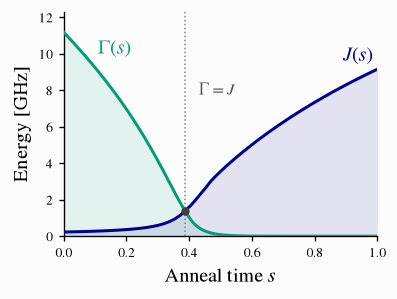

schedule: 1001 points, Gamma 11.19->0.00 GHz, J 0.23->9.15 GHz, crossover s=0.388
width in = 3.375


In [3]:
# D-Wave quantum-anneal schedule Gamma(s), J(s) (GHz) driving the quench.
from src.exact import load_schedule

s_sched, gamma, Jc = load_schedule("data_dwave/qa_schedule.csv")
C_GAMMA, C_J = "#029E73", "#00008C"
PANEL_FILL = (0.99, 0.99, 0.99)  # tikz black!1  (1% black -> 99% white)

fig, ax = plt.subplots(figsize=(COL1, COL1 * 0.72))
fig.patch.set_facecolor(PANEL_FILL)  # figure + axes background = panel fill
ax.set_facecolor(PANEL_FILL)

# curves + light fill (schedule-diagram look)
ax.plot(s_sched, gamma, "-", color=C_GAMMA, lw=1.8, zorder=3)
ax.plot(s_sched, Jc, "-", color=C_J, lw=1.8, zorder=3)
ax.fill_between(s_sched, gamma, 0, color=C_GAMMA, alpha=0.10, lw=0, zorder=1)
ax.fill_between(s_sched, Jc, 0, color=C_J, alpha=0.10, lw=0, zorder=1)

# inline curve labels instead of a legend box (cleaner as an overview panel)
ax.annotate(r"$\Gamma(s)$", xy=(0.10, float(np.interp(0.10, s_sched, gamma))),
            xytext=(2, 5), textcoords="offset points", color=C_GAMMA,
            fontsize=12, ha="left", va="bottom")
ax.annotate(r"$J(s)$", xy=(0.88, float(np.interp(0.88, s_sched, Jc))+0.8),
            xytext=(2, 4.5), textcoords="offset points", color=C_J,
            fontsize=12, ha="left", va="bottom")

# Gamma(s) = J(s) crossover, near the critical region of the quench
i_cross = int(np.argmin(np.abs(gamma - Jc)))
ax.axvline(s_sched[i_cross], color="0.5", ls=":", lw=0.9, zorder=2)
ax.plot(s_sched[i_cross], gamma[i_cross], "o", ms=4, color="0.25", zorder=5)
ax.annotate(rf"$\Gamma=J$",
            xy=(0.4, 6.8), xytext=(6, 10), textcoords="offset points",
            fontsize=10, color="0.3")

ax.set_xlim(0, 1)
ax.set_ylim(0, max(float(gamma.max()), float(Jc.max())) * 1.10)
ax.set_xlabel(r"Anneal time $s$", fontsize=12)
ax.set_ylabel("Energy [GHz]", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="both", labelsize=8, direction="out")
ax.minorticks_off()
# fig.tight_layout()
# facecolor=PANEL_FILL so the saved PDF keeps the panel-fill background (not white)
fig.savefig(f"{FIGDIR}/fig_qa_schedule.pdf", facecolor=PANEL_FILL)  # backward-compatible name
plt.show()
print(f"schedule: {len(s_sched)} points, Gamma {gamma[0]:.2f}->{gamma[-1]:.2f} GHz, "
      f"J {Jc[0]:.2f}->{Jc[-1]:.2f} GHz, crossover s={s_sched[i_cross]:.3f}")
print("width in =", fig.get_size_inches()[0])

## Ablation experiments

Three methodological diagnostics side by side, each reusing an existing experiment's data:

- **(a)** the parallel-tempering sampler's per-$\beta$ acceptance vs $s$ (`local_vs_pt`) —
colored hot→cold, with the local sampler dashed for reference

- **(b)** the correlator inter-chain $\hat R$ vs $s$ for raw (`q=0`) vs blurred (`q=0.3`) sampling,
with the normalized blurred-sampling ESS inset (`blurred_sampling`).

- **(c)** the cached vs uncached RK45 adaptive step $dt$ vs $s$ (`cached_rk45`)

(a) Local MCMC eps_c(s=1) = 0.4096 +/- 0.0027
(a) PT         eps_c(s=1) = 0.0331 +/- 0.0003
(b) Standard (q=0.0) eps_c(s=1) = 0.2434 +/- 0.0002
(b) Blurred  (q=0.3) eps_c(s=1) = 0.0338 +/- 0.0003


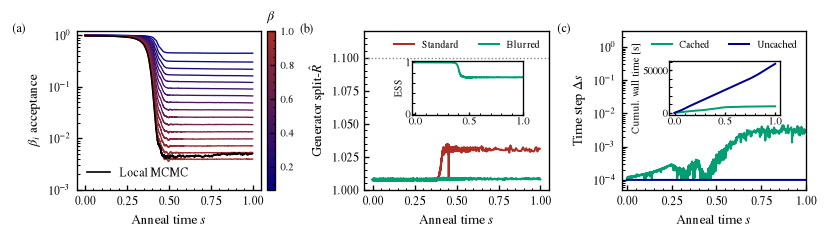

In [4]:
# Combined experiments: three methodological diagnostics in one double-column row,
# each reusing an existing experiment's on-disk data (no new computation):
#   (a) PT per-beta acceptance vs s          (local_vs_pt)
#   (b) cached vs uncached RK45 dt vs s       (cached_rk45)
#   (c) correlator R_hat vs s + ESS inset     (blurred_sampling)
from matplotlib.colors import LinearSegmentedColormap
# beta colorbar: linear ramp COLORBLIND[1] (orange) -> COLORBLIND[2] (green)
beta_cmap = LinearSegmentedColormap.from_list(
    "beta_cb12", [COLORBLIND[1], COLORBLIND[2]]
)
fig, axes = plt.subplots(1, 3, figsize=(COL2, COL2 * 0.28), constrained_layout=True)

# -- (a) parallel-tempering per-beta acceptance vs s (biclique 2x6x6, R=3) --------------
ax = axes[0]
pt_runs = {cfg["sampler"]: sp for cfg, sp in find_paper_run("local_vs_pt")}
log_pt = load_log(pt_runs.get("pt")) if pt_runs.get("pt") else None
log_loc = load_log(pt_runs.get("local")) if pt_runs.get("local") else None
if log_pt and "pt_accept_per_beta" in log_pt:
    e = log_pt["pt_accept_per_beta"]
    M = np.asarray(e["value"], float)              # (n_steps, n_replicas), hot->cold
    s_pt = to_s(log_pt, np.asarray(e["iters"], float))
    R = M.shape[1]
    betas = np.arange(1, R + 1) / R                # ascending hot->cold: [1/R, ..., 1]
    cmap = beta_cmap(np.linspace(0, 1, R))
    for j in range(R):
        ax.plot(s_pt, M[:, j], "-", color=cmap[j], lw=0.8)
    sm = plt.cm.ScalarMappable(cmap=beta_cmap, norm=plt.Normalize(betas[0], betas[-1]))
    sm.set_array([])
    cb = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.05)
    cb.ax.set_title(r"$\beta$", fontsize=FS_LABEL); cb.ax.tick_params(labelsize=FS_SMALL)
else:
    print(f"(a) pt: no pt_accept_per_beta at {pt_runs.get('pt')}")
if log_loc and "acceptance" in log_loc:
    it, acc = series(log_loc, "acceptance")
    ax.plot(to_s(log_loc, it), acc, "-", color="k", lw=1.0, label="Local MCMC")
    ax.legend(frameon=False, fontsize=FS_TICK, loc="lower left")
ax.set_yscale("log"); ax.set_ylim(1e-3, 1.2)
ax.set_xlabel(r"Anneal time $s$"); ax.set_ylabel(r"$\beta_i$ acceptance")
ax.text(-0.35, 1.05, "(a)", transform=ax.transAxes, ha="left", va="top", fontsize=FS_TICK)
# eps_c at the end of the anneal (s=1) for the two samplers shown in this panel
for lbl, key in (("Local MCMC", "local"), ("PT", "pt")):
    sp_ = pt_runs.get(key)
    e_, es_ = best_corr_error(sp_, 1.0, with_err=True) if sp_ else (np.nan, np.nan)
    print(f"(a) {lbl:10s} eps_c(s=1) = {e_:.4f} +/- {es_:.4f}")

# -- (b) correlator inter-chain R_hat vs s + ESS inset (glassy biclique 2x6x6, R=3) -----
ax = axes[1]
bl_runs = {float(cfg.get("q", 0.0)): sp for cfg, sp in find_paper_run("blurred_sampling")}
QVALS = [0.0, 0.3]
COL_BL = {0.0: COLORBLIND[2], 0.3: COLORBLIND[0]}
LAB_BL = {0.0: r"Standard", 0.3: r"Blurred"}
idx = 0
for q in QVALS:
    log = load_log(bl_runs.get(q)) if bl_runs.get(q) else None
    if not log or "Generator" not in log:
        print(f"(c) q={q}: pending ({bl_runs.get(q)})"); continue
    it, v = generator_field(log, "R_hat")
    ax.plot(to_s(log, it), v, "-", color=COL_BL[q], label=LAB_BL[q])
ax.axhline(1.1, color="0.5", ls=":", lw=0.8)
ax.set_xlabel(r"Anneal time $s$"); ax.set_ylabel(r"Generator split-$\hat{R}$")
ax.set_ylim(1, 1.12)
ax.text(-0.35, 1.05, "(b)", transform=ax.transAxes, ha="left", va="top", fontsize=FS_TICK)
ax.legend(frameon=False, loc="upper right", fontsize=6, ncol=2)
# inset: normalized blurred-sampling ESS vs s (empty upper-left corner)
axi = ax.inset_axes([0.26, 0.47, 0.60, 0.34])
log = load_log(bl_runs.get(QVALS[1])) if bl_runs.get(QVALS[1]) else None
if log and f"{idx}/ess_blurred" in log:
    it, v = series(log, f"{idx}/ess_blurred")
    axi.plot(to_s(log, it), v, "-", color=COL_BL[QVALS[1]])
axi.set_xlim(-0.03, 1); axi.set_ylim(-0.03, 1.02)
axi.tick_params(labelsize=FS_SMALL, length=2, pad=1)
axi.set_ylabel("ESS", fontsize=FS_SMALL, labelpad=1)
# eps_c at the end of the anneal (s=1) for the two sampling schemes shown here
for q in QVALS:
    sp_ = bl_runs.get(q)
    e_, es_ = best_corr_error(sp_, 1.0, with_err=True) if sp_ else (np.nan, np.nan)
    print(f"(b) {LAB_BL[q]:8s} (q={q}) eps_c(s=1) = {e_:.4f} +/- {es_:.4f}")


# -- (c) cached vs uncached RK45 adaptive step dt vs s (3ddimer 3x2x2) ------------------
ax = axes[2]
rk_runs = {bool(cfg["cache_within_step"]): sp for cfg, sp in find_paper_run("cached_rk45")}
COL_RK = {True: COLORBLIND[0], False: COLORBLIND[1]}
LAB_RK = {True: "Cached", False: "Uncached"}
axi = ax.inset_axes([0.26, 0.47, 0.60, 0.34])
for cached in (True, False):
    log = load_log(rk_runs.get(cached)) if rk_runs.get(cached) else None
    if not log:
        print(f"(c) {LAB_RK[cached]}: no log at {rk_runs.get(cached)}"); continue
    it, dt = series(log, "dt")
    ax.plot(to_s(log, it), dt, "-", color=COL_RK[cached], label=LAB_RK[cached])
    if not log or "time/total" not in log:
        continue
    it, tt = series(log, "time/total")
    s = to_s(log, it); cum = np.cumsum(tt)
    axi.plot(s, cum, "-", color=COL_RK[cached])
    axi.set_ylabel("Cumul. wall time [s]", fontsize=FS_SMALL, labelpad=1)
    axi.tick_params(labelsize=FS_SMALL, length=2, pad=1)
ax.set_yscale("log"); ax.set_xlim(-0.03, 1.); ax.set_ylim(5e-5, 3e0)
ax.set_xlabel(r"Anneal time $s$"); ax.set_ylabel(r"Time step $\Delta s$")
ax.text(-0.35, 1.05, "(c)", transform=ax.transAxes, ha="left", va="top", fontsize=FS_TICK)
ax.legend(frameon=False, fontsize=6, ncol=2)

fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)
fig.savefig(f"{FIGDIR}/fig_combined_experiments.pdf"); plt.show()

## Combined training wall time over all runs

Sums per-step `time/total` from *every* run's NetKet `log.json` under the `EXPERIMENTS` folders -- all topologies, sizes, instances and ranks -- and reports the combined total.

In [5]:
# Combined training wall time over ALL runs in the final experiments.
# EXPERIMENTS comes from the setup cell.
wt_recs = scan_all_walltimes(list(EXPERIMENTS.values()))

# ---- breakdown by (t_a, topology) -----------------------------------------
hdr = (f"{'t_a':>4} {'topology':<9} {'logs':>5} {'done':>5} "
       f"{'steps':>7} {'walltime_s':>12} {'h:mm:ss':>11} {'days':>7}")
print(hdr)
print("-" * len(hdr))

keys = sorted({(r["t_a"], r["topology"]) for r in wt_recs})
subtotals = {}
for ta, topo in keys:
    sub = [r for r in wt_recs if r["t_a"] == ta and r["topology"] == topo]
    wt = sum(r["walltime"] for r in sub)
    subtotals[ta] = subtotals.get(ta, 0.0) + wt
    print(f"{ta:>4.0f} {topo:<9} {len(sub):>5} {sum(r['done'] for r in sub):>5} "
          f"{sum(r['n_steps'] for r in sub):>7} {wt:>12.1f} {_hms(wt):>11} "
          f"{wt / 86400:>7.2f}")

print()
for ta in sorted(subtotals):
    n = sum(1 for r in wt_recs if r["t_a"] == ta)
    tot = subtotals[ta]
    print(f"t_a={ta:>4.0f} ns subtotal ({n:>3} logs): {tot:>12.1f} s = "
          f"{tot / 3600:8.2f} h = {tot / 86400:6.2f} days")

top = max(wt_recs, key=lambda r: r["walltime"])
print()
print(f"MOST EXPENSIVE RUN: {top['walltime']:.1f} s = {top['walltime'] / 3600:.2f} h "
      f"= {top['walltime'] / 86400:.2f} days ({_hms(top['walltime'])})")
print(f"  {top['topology']}_{top['shape']} instance_{top['instance']} "
      f"t_a={top['t_a']:.0f} R{top['rank']} | {top['n_steps']} steps, "
      f"{'done' if top['done'] else 'NOT DONE'}")
print(f"  {top['path']}")

grand_total = sum(r["walltime"] for r in wt_recs)
n_done = sum(r["done"] for r in wt_recs)
n_runs = len({os.path.dirname(r["path"]) for r in wt_recs})
print()
print(f"COMBINED TOTAL over {len(wt_recs)} logs in {n_runs} run folders "
      f"({n_done} reached s=1): {grand_total:.1f} s = {grand_total / 3600:.2f} h "
      f"= {grand_total / 86400:.2f} days ({_hms(grand_total)})")

 t_a topology   logs  done   steps   walltime_s     h:mm:ss    days
-------------------------------------------------------------------
   7 2d           40    40  109114    1470281.7   408:24:41   17.02
   7 3ddimer      24    24   71349     735610.1   204:20:10    8.51
   7 biclique     40    40  132314     605819.7   168:16:59    7.01
   7 diamond      16    16   37943     110956.0    30:49:16    1.28
  20 2d           40    40  188933    2249890.5   624:58:10   26.04
  20 3ddimer      24    24  116333    1461022.6   405:50:22   16.91
  20 biclique     40    40  186740     786538.2   218:28:58    9.10
  20 diamond      16    16   69348     222751.7    61:52:31    2.58

t_a=   7 ns subtotal (120 logs):    2922667.5 s =   811.85 h =  33.83 days
t_a=  20 ns subtotal (120 logs):    4720203.0 s =  1311.17 h =  54.63 days

MOST EXPENSIVE RUN: 393298.1 s = 109.25 h = 4.55 days ( 109:14:58)
  2d_8x8 instance_0 t_a=20 R4 | 6156 steps, done
  ./data/tvmc/final_20/2d_8x8/instance_0/t_a_20/jast

## TDVP residual

- **Figure 1** (`fig_tdvp_residual_epsc.pdf`) — correlation error $\epsilon_c$ vs the anneal-averaged
  residual $\mathcal{R}^2$, with the 5% target dashed.
- **Figure 2** (`fig_tdvp_residual_size.pdf`) — $\mathcal{R}^2$ vs system size $N$, median over
  disorder instances with the min--max spread as the bar.

Each figure is two glued 2×2 blocks, $t_a=7$ ns and $t_a=20$ ns.

clean runs: 236 / 240   (stage 0, coverage > 0.98, s_max > 0.98)
excluded:
   t_a=20  3ddimer  3x2x2 N=24 R4  coverage=0.455 s_max=0.999   non-finite eps^2
   t_a=20 biclique  2x5x5 N=20 R1  coverage=0.761 s_max=0.999   non-finite eps^2
   t_a=20 biclique  2x5x5 N=20 R2  coverage=0.684 s_max=0.993   non-finite eps^2
   t_a=20 biclique  2x5x5 N=20 R4  coverage=0.447 s_max=0.997   non-finite eps^2
global eps_c ~ (R^2)^0.545   (R^2 of fit 0.50, 236 runs)


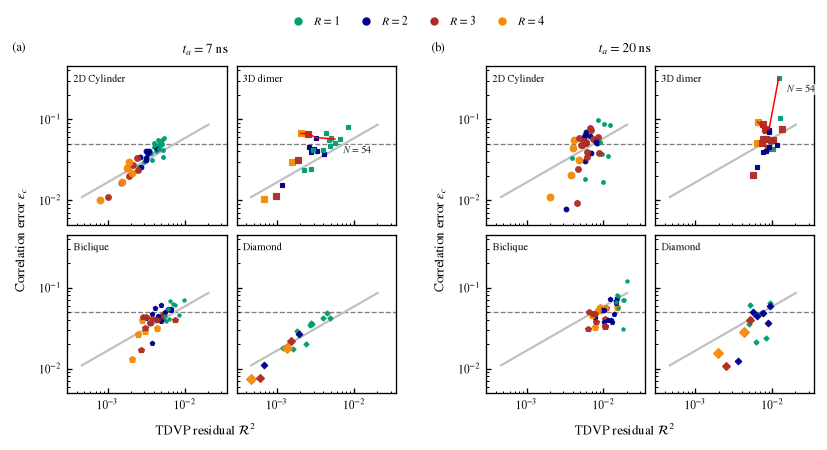

t_a= 7 ns  R^2 ~ N^alpha per topology: 2D Cylinder +0.47  3D dimer +0.95  Biclique +0.97  Diamond +1.37
t_a=20 ns  R^2 ~ N^alpha per topology: 2D Cylinder +0.28  3D dimer +0.21  Biclique +0.59  Diamond +1.11


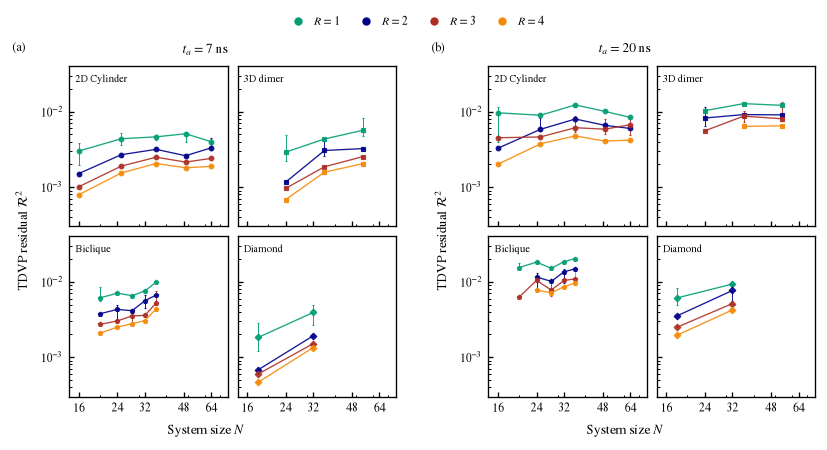

In [6]:
# --- TDVP residual: what it buys in eps_c, and what size costs --------------

# S, STAGE, EXPERIMENTS, RANKS, COV_MIN/S_MAX_MIN, TOPOS and the TOPO_* tables
# come from the setup cell.
# (topology, N) whose rank points are joined by an eye-guide line in block (a)
TRACE = {("3ddimer", 54)}
SMOOTH = 100                     # rolling-median window, in logged steps



def _eps2_trajectory(log, stage=STAGE):
    """(s, eps^2, <R^2>) for one run: the stage-`stage` residual over the anneal
    and its dt-weighted mean. eps^2 and dt are History series on a shared
    iters(=s) axis whose lengths differ by one, so they are aligned on iters
    (same alignment as _tdvp_residual in the cell above)."""
    ie, eps = series(log, f"{stage}/epsilon_squared")
    idt, dt = series(log, "dt")
    dt_by_it = dict(zip(idt, dt))
    w = np.array([dt_by_it.get(i, 0.0) for i in ie])
    m = np.isfinite(eps) & (w > 0)
    r2 = float(np.sum(eps[m] * w[m]) / w[m].sum()) if m.any() else np.nan
    return ie, eps, r2


def _rolling_median(y, window=SMOOTH):
    """Centered rolling median with edge padding (keeps len(y))."""
    k = max(3, int(window) | 1)
    yp = np.pad(np.asarray(y, float), k // 2, mode="edge")
    return np.array([np.median(yp[i:i + k]) for i in range(len(y))])

def _tdvp_residual(log, stage=STAGE):
    """(<R^2>, coverage) for one run: the dt-weighted mean of stage `stage`'s
    epsilon_squared over the anneal, and the fraction of the total dt weight on
    which epsilon_squared is finite.

    eps^2 and dt are History series on a shared iters(=s) axis whose lengths
    differ by one (dt carries the extra s=0 pre-step point), so they are aligned
    on iters rather than zipped. Five of the 120 final runs have non-finite eps^2
    over part of the anneal; those entries are dropped from the mean and reported
    through `coverage` so the caller can gate on them -- silently averaging what
    is left biases <R^2> low (it removes exactly the hard part of the anneal) and
    flips the fitted N exponent negative.
    """
    if log is None or f"{stage}/epsilon_squared" not in log or "dt" not in log:
        return np.nan, 0.0
    ie, eps = series(log, f"{stage}/epsilon_squared")
    idt, dt = series(log, "dt")
    dt_by_it = dict(zip(idt, dt))
    w = np.array([dt_by_it.get(i, 0.0) for i in ie])
    m = np.isfinite(eps) & (w > 0)
    if w.sum() <= 0 or not m.any():
        return np.nan, 0.0
    return float(np.sum(eps[m] * w[m]) / w[m].sum()), float(w[m].sum() / w.sum())


def scan_experiment_logs(experiment, data_dir=DATA_DIR):
    """Path-parsed inventory of every run folder holding a log.json under
    data/tvmc/<experiment>/ -- the log-side twin of scan_experiment_corrs, so it
    also sees runs with no corrs file yet (e.g. an anneal that never finished).
    Records: {experiment, topology, shape, instance, t_a, rank, r2, coverage,
    s_max, save_path}."""
    experiments = [experiment] if isinstance(experiment, str) else list(experiment)
    recs = []
    for exp in experiments:
        base = os.path.join(data_dir, "tvmc", exp)
        for f in glob.glob(os.path.join(base, "*", "instance_*", "**", "log.json"),
                           recursive=True):
            rel = os.path.relpath(f, base).split(os.sep)
            topo, _, shp = rel[0].partition("_")
            inst = int(next(p for p in rel if p.startswith("instance_")).split("_")[1])
            t_a = float(next(p for p in rel if p.startswith("t_a_"))[len("t_a_"):])
            model_seg = next((p for p in rel if p.startswith(("jastrow", "rbm"))), "")
            mr = re.search(r"_r(\d+)", model_seg)
            sp = os.path.dirname(f)
            log = load_log(sp)
            r2, cov = _tdvp_residual(log)
            recs.append(dict(experiment=exp, topology=topo, shape=shp, instance=inst,
                             t_a=t_a, rank=int(mr.group(1)) if mr else 1,
                             r2=r2, coverage=cov,
                             s_max=float(series(log, "t")[1][-1]), save_path=sp))
    return recs


def _log_ticks(ax, which, ticks, labels=None):
    """Explicit major ticks on a log axis, with minor tick labels suppressed --
    over a range under one decade matplotlib labels the minor ticks too, which
    collides with hand-chosen majors like the N values used here."""
    a = ax.xaxis if which == "x" else ax.yaxis
    a.set_major_locator(matplotlib.ticker.FixedLocator(ticks))
    a.set_major_formatter(matplotlib.ticker.FixedFormatter(
        labels if labels is not None else [f"{t:g}" for t in ticks]))
    a.set_minor_formatter(matplotlib.ticker.NullFormatter())


def _powfit(x, y):
    """(slope, intercept, R^2) of a straight-line fit in log10-log10 space."""
    lx, ly = np.log10(np.asarray(x, float)), np.log10(np.asarray(y, float))
    slope, intercept = np.polyfit(lx, ly, 1)
    ss = np.sum((ly - ly.mean()) ** 2)
    r2 = 1 - np.sum((ly - (slope * lx + intercept)) ** 2) / ss if ss > 0 else np.nan
    return float(slope), float(intercept), float(r2)


def _shared_slope_fit(x, y, groups):
    """Common log-log slope with a per-group intercept: log10 y = a log10 x + c_g.
    Used for the N exponent of a topology, where each (t_a, rank) family has its
    own amplitude but the exponent is the quantity of interest -- pooling the raw
    points instead would let those amplitude offsets masquerade as a slope."""
    gs = sorted(set(groups))
    if len(x) <= len(gs):
        return np.nan, {}
    A = np.zeros((len(x), 1 + len(gs)))
    A[:, 0] = np.log10(x)
    for i, g in enumerate(groups):
        A[i, 1 + gs.index(g)] = 1.0
    coef, *_ = np.linalg.lstsq(A, np.log10(y), rcond=None)
    return float(coef[0]), {g: float(coef[1 + i]) for i, g in enumerate(gs)}


# ---- build one record per run, joining the log side to the corrs side -------
logs = scan_experiment_logs(list(EXPERIMENTS.values()))
best = {}                                  # largest eval N_s per run at s=S
for r in scan_experiment_corrs(list(EXPERIMENTS.values())):
    if abs(r["s"] - S) > 1e-6:
        continue
    k = (r["topology"], r["shape"], r["instance"], r["t_a"], r["rank"])
    if k not in best or r["n_samples"] > best[k]["n_samples"]:
        best[k] = r


# (topology, shape) -> N, so a run with no corrs file still gets its N
nsites = {(r["topology"], r["shape"]): _nsites(r["path"]) for r in best.values()}
runs = []
for r in logs:
    c = best.get((r["topology"], r["shape"], r["instance"], r["t_a"], r["rank"]))
    runs.append(dict(r, N=nsites.get((r["topology"], r["shape"]), np.nan),
                     eps_c=c["eps_c_mps"] if c else np.nan,
                     eps_c_std=c["eps_c_mps_std"] if c else np.nan))
for r in runs:
    r["ok"] = bool(r["coverage"] > COV_MIN and r["s_max"] > S_MAX_MIN
                   and np.isfinite(r["r2"]) and np.isfinite(r["N"]))
clean_res = [r for r in runs if r["ok"]]
print(f"clean runs: {len(clean_res)} / {len(runs)}   (stage {STAGE}, "
      f"coverage > {COV_MIN}, s_max > {S_MAX_MIN})")
print("excluded:")
for r in sorted([r for r in runs if not r["ok"]],
                key=lambda z: (z["t_a"], z["topology"], z["N"], z["rank"])):
    why = ("truncated anneal" if r["s_max"] <= S_MAX_MIN else
           "non-finite eps^2" if r["coverage"] <= COV_MIN else "no <R^2>")
    print(f"   t_a={r['t_a']:>2.0f} {r['topology']:>8} {r['shape']:>6} N={r['N']:>2.0f}"
          f" R{r['rank']}  coverage={r['coverage']:.3f} s_max={r['s_max']:.3f}   {why}")

# the eps_c(R^2) relation is one law for the whole dataset, so its reference fit
# is made once over both anneal times and drawn identically in both figures
val_all = [r for r in clean_res if np.isfinite(r["eps_c"])]
sl, ic, r2g = _powfit([r["r2"] for r in val_all], [r["eps_c"] for r in val_all])
xg = np.array([min(r["r2"] for r in val_all), max(r["r2"] for r in val_all)])
print(f"global eps_c ~ (R^2)^{sl:.3f}   (R^2 of fit {r2g:.2f}, {len(val_all)} runs)")
alpha_N = {}                            # (t_a, topology) -> (exponent, #sizes, #runs)


def _rank_key(fig):
    """The key shared by every panel: color = ansatz rank (marker = topology is
    named inside each panel, and t_a labels the block). It belongs to the figure
    rather than to one axes -- cells 4 and 10 place it the same way."""
    fig.legend(handles=[plt.Line2D([], [], marker="o", ls="none", ms=4,
                                   color=rank_col[rk], label=f"$R={rk}$")
                        for rk in RANKS],
               fontsize=FS_TICK, ncol=4, loc="upper center",
               bbox_to_anchor=(0.5, 1.08), handletextpad=0.4, columnspacing=1.2)


# ==== Figure 1: what rank buys -- eps_c vs the residual ======================
# Two glued 2x2 blocks, one anneal time each, one topology per panel, shared axes.
fig = plt.figure(figsize=(COL2, COL2 * 0.5), constrained_layout=True)
for sf, lab, ta in zip(fig.subfigures(1, 2, wspace=0.07), "ab", EXPERIMENTS):
    axs = sf.subplots(2, 2, sharex=True, sharey=True,
                      gridspec_kw={"wspace": 0, "hspace": 0}).ravel()
    # a suptitle (not free text), centered over the block: constrained_layout
    # then reserves the space, so it cannot land on top of the first panel.
    # The block letter goes at the left end of that same reserved row.
    sf.suptitle(f"$t_a = {ta:g}$ ns", fontsize=FS_LABEL)
    sf.text(0.005, 0.99, f"({lab})", fontsize=FS_TICK, ha="left", va="top")
    val = [r for r in clean_res if np.isfinite(r["eps_c"]) and r["t_a"] == ta]
    for ax, topo in zip(axs, TOPOS):
        sub = [r for r in val if r["topology"] == topo]
        ax.plot(xg, 10 ** (sl * np.log10(xg) + ic), color="0.75", lw=1.3, zorder=2)
        # eye-guide along rank for the series listed in TRACE: the points are
        # joined in rank order (R = 1 -> 4), at the median over disorder instances
        # of both coordinates, so the line is defined where several were run
        for Ntr in sorted({r["N"] for r in sub if (topo, r["N"]) in TRACE}):
            pts = [(np.median([r["r2"] for r in g]),
                    np.median([r["eps_c"] for r in g]))
                   for g in ([r for r in sub if r["N"] == Ntr and r["rank"] == rk]
                             for rk in RANKS) if g]
            if len(pts) < 2:
                continue
            # over the markers (they are dense enough here to hide a line drawn
            # under them), labelled at the R = 1 end
            ax.plot(*zip(*pts), ls="-", lw=0.9, color="red", alpha=1., zorder=6)
            ax.annotate(f"$N={Ntr:g}$", pts[0], textcoords="offset points",
                        xytext=(5, -4), fontsize=FS_SMALL, color="0.15",
                        ha="left", va="top", zorder=7,
                        bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.4))
        for r in sub:
            ax.errorbar(r["r2"], r["eps_c"], yerr=_yerr([r["eps_c_std"]]),
                        fmt=TOPO_MARKER[topo], ms=1.6 + 0.6 * r["rank"], mew=0.7,
                        color=rank_col[r["rank"]], alpha=0.95,
                        mfc=rank_col[r["rank"]],
                        ecolor=rank_col[r["rank"]], elinewidth=0.6, capsize=0.8,
                        ls="none", zorder=5)
        ax.axhline(REF, color="0.5", ls="--", lw=0.8, zorder=1)
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(3e-4, 3.5e-2); ax.set_ylim(5e-3, 0.45)
        ax.tick_params(labelsize=FS_TICK)
        ax.text(0.04, 0.95, TOPO_LABEL[topo], transform=ax.transAxes,
                fontsize=FS_SMALL, ha="left", va="top")
    sf.supxlabel(r"TDVP residual $\mathcal{R}^2$", fontsize=FS_LABEL)
    sf.supylabel(r"Correlation error $\epsilon_c$", fontsize=FS_LABEL)

_rank_key(fig)
fig.savefig(f"{FIGDIR}/fig_tdvp_residual_epsc.pdf"); plt.show()

# ==== Figure 2: what size costs -- the residual vs N =========================
fig = plt.figure(figsize=(COL2, COL2 * 0.5), constrained_layout=True)
for sf, lab, ta in zip(fig.subfigures(1, 2, wspace=0.07), "ab", EXPERIMENTS):
    axs = sf.subplots(2, 2, sharex=True, sharey=True,
                      gridspec_kw={"wspace": 0, "hspace": 0}).ravel()
    # a suptitle (not free text), centered over the block: constrained_layout
    # then reserves the space, so it cannot land on top of the first panel.
    # The block letter goes at the left end of that same reserved row.
    sf.suptitle(f"$t_a = {ta:g}$ ns", fontsize=FS_LABEL)
    sf.text(0.005, 0.99, f"({lab})", fontsize=FS_TICK, ha="left", va="top")
    for ax, topo in zip(axs, TOPOS):
        sub = [r for r in clean_res if r["topology"] == topo and r["t_a"] == ta]
        for rk in RANKS:
            ser = [r for r in sub if r["rank"] == rk]
            if not ser:
                continue
            by_N = {}
            for r in ser:
                by_N.setdefault(r["N"], []).append(r["r2"])
            Ns = sorted(by_N)
            # bar = full min-max spread over the instances at that N; it
            # collapses to zero where only one instance was run
            med = np.array([np.median(by_N[n]) for n in Ns])
            lo = np.array([np.min(by_N[n]) for n in Ns])
            hi = np.array([np.max(by_N[n]) for n in Ns])
            ax.errorbar(Ns, med, yerr=[med - lo, hi - med],
                        ls="-", lw=0.8, color=rank_col[rk], alpha=0.9,
                        marker=TOPO_MARKER[topo], ms=2.8, mew=0.7,
                        mfc=rank_col[rk],
                        ecolor=rank_col[rk], elinewidth=0.6, capsize=0.8, zorder=3)
        # one exponent per topology: a slope shared by every rank family at this
        # t_a, each of which keeps its own amplitude
        a, _ = _shared_slope_fit([r["N"] for r in sub], [r["r2"] for r in sub],
                                 [r["rank"] for r in sub])
        alpha_N[(ta, topo)] = (a, len({r["N"] for r in sub}), len(sub))
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(14.5, 76); ax.set_ylim(3e-4, 4e-2)
        _log_ticks(ax, "x", [16, 24, 32, 48, 64])
        ax.tick_params(labelsize=FS_TICK)
        ax.text(0.04, 0.95, TOPO_LABEL[topo], transform=ax.transAxes,
                fontsize=FS_SMALL, ha="left", va="top")
    sf.supxlabel(r"System size $N$", fontsize=FS_LABEL)
    sf.supylabel(r"TDVP residual $\mathcal{R}^2$", fontsize=FS_LABEL)
    print(f"t_a={ta:>2} ns  R^2 ~ N^alpha per topology: "
          + "  ".join(f"{TOPO_LABEL[t]} {alpha_N[(ta, t)][0]:+.2f}" for t in TOPOS))

_rank_key(fig)
fig.savefig(f"{FIGDIR}/fig_tdvp_residual_size.pdf"); plt.show()


## RK45 steps vs system size

Does the adaptive RK45 controller need a smaller $dt$ -- and therefore more steps -- for larger
systems? 

runs with a step count: 240 / 240
t_a= 7 ns: shared-slope exponent +0.372   (pooled fit +0.410, R^2=0.23, 120 runs)
      2D Cylinder: +0.405  (40 runs, 5 sizes)
         3D dimer: +0.295  (24 runs, 3 sizes)
         Biclique: +0.497  (40 runs, 5 sizes)
          Diamond: +0.181  (16 runs, 2 sizes)
t_a=20 ns: shared-slope exponent +0.056   (pooled fit +0.147, R^2=0.27, 120 runs)
      2D Cylinder: +0.084  (40 runs, 5 sizes)
         3D dimer: -0.017  (24 runs, 3 sizes)
         Biclique: +0.025  (40 runs, 5 sizes)
          Diamond: +0.031  (16 runs, 2 sizes)


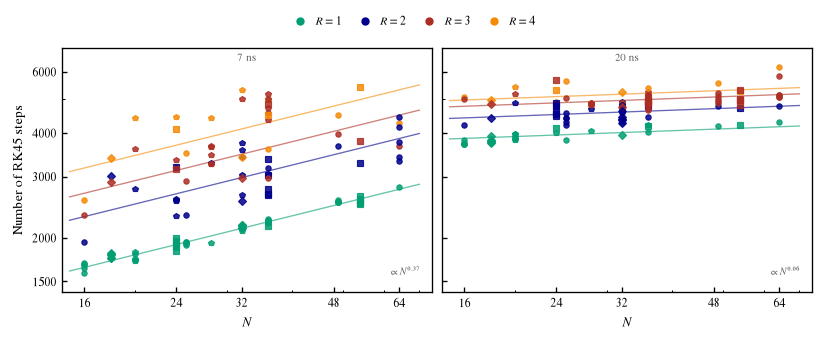

In [7]:
# --- adaptive-integrator cost: RK45 steps vs system size -------------------

# EXPERIMENTS, RANKS, S_MAX_MIN (drops truncated anneals, which have fewer steps
# by construction), TOPOS, the TOPO_* tables and _nsites_shape come from the
# setup cell.


def scan_experiment_steps(experiment, data_dir=DATA_DIR):
    """One record per run folder: accepted RK45 steps and where the anneal ended.
    Path-parsed like scan_experiment_logs, but loads each log only once."""
    experiments = [experiment] if isinstance(experiment, str) else list(experiment)
    recs = []
    for exp in experiments:
        base = os.path.join(data_dir, "tvmc", exp)
        for f in glob.glob(os.path.join(base, "*", "instance_*", "**", "log.json"),
                           recursive=True):
            rel = os.path.relpath(f, base).split(os.sep)
            topo, _, shp = rel[0].partition("_")
            inst = int(next(p for p in rel if p.startswith("instance_")).split("_")[1])
            t_a = float(next(p for p in rel if p.startswith("t_a_"))[len("t_a_"):])
            model_seg = next((p for p in rel if p.startswith(("jastrow", "rbm"))), "")
            mr = re.search(r"_r(\d+)", model_seg)
            log = load_log(os.path.dirname(f))
            t = series(log, "t")[1] if log and "t" in log else np.array([])
            recs.append(dict(experiment=exp, topology=topo, shape=shp, instance=inst,
                             t_a=t_a, rank=int(mr.group(1)) if mr else 1,
                             n_steps=float(len(t)) if len(t) else np.nan,
                             s_end=float(t[-1]) if len(t) else np.nan,
                             save_path=os.path.dirname(f)))
    return recs


steps = scan_experiment_steps(list(EXPERIMENTS.values()))
nsites = {}                                     # (topology, shape) -> N
for r in steps:
    k = (r["topology"], r["shape"])
    if not np.isfinite(nsites.get(k, np.nan)):
        nsites[k] = _nsites_shape(r["save_path"])
for r in steps:
    r["N"] = nsites.get((r["topology"], r["shape"]), np.nan)
    r["ok"] = bool(np.isfinite(r["n_steps"]) and np.isfinite(r["N"])
                   and r["s_end"] > S_MAX_MIN)
clean_steps = [r for r in steps if r["ok"]]
print(f"runs with a step count: {len(clean_steps)} / {len(steps)}")
for r in [r for r in steps if not r["ok"]]:
    print(f"   dropped t_a={r['t_a']:>2.0f} {r['topology']:>8} {r['shape']:>6} "
          f"R{r['rank']} inst {r['instance']}  s_end={r['s_end']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(COL2, COL2 * 0.36), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (ta, lab) in zip(axes, zip(EXPERIMENTS, "ab")):
    sub = [r for r in clean_steps if r["t_a"] == ta]
    for r in sub:
        ax.plot(r["N"], r["n_steps"], TOPO_MARKER[r["topology"]], ms=3.2, mew=0.7,
                color=rank_col[r["rank"]], mfc=rank_col[r["rank"]], alpha=0.85,
                zorder=4)
    a, ics = _shared_slope_fit([r["N"] for r in sub], [r["n_steps"] for r in sub],
                               [(r["topology"], r["rank"]) for r in sub])
    sl, _, rr = _powfit([r["N"] for r in sub], [r["n_steps"] for r in sub])
    xg = np.array([15.0, 70.0])
    for rk in RANKS:
        c = [v for k, v in ics.items() if k[1] == rk]
        if c:
            ax.plot(xg, 10 ** (a * np.log10(xg) + np.median(c)), color=rank_col[rk],
                    lw=0.8, alpha=0.6, zorder=2)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(14.5, 74); ax.set_ylim(1.4e3, 7e3)
    _log_ticks(ax, "x", [16, 24, 32, 48, 64])
    _log_ticks(ax, "y", [1500, 2000, 3000, 4000, 6000])
    ax.tick_params(labelsize=FS_TICK)
    ax.text(0.5, 0.98, f"{ta} ns", transform=ax.transAxes,
                    ha="center", va="top", fontsize=FS_SMALL, color="0.35")
    ax.text(0.97, 0.06, rf"$\propto N^{{{a:.2f}}}$", transform=ax.transAxes,
            fontsize=FS_SMALL, ha="right", va="bottom", color="0.35")
    print(f"t_a={ta:>2} ns: shared-slope exponent {a:+.3f}   "
          f"(pooled fit {sl:+.3f}, R^2={rr:.2f}, {len(sub)} runs)")
    for topo in TOPOS:
        st = [r for r in sub if r["topology"] == topo]
        at, _ = _shared_slope_fit([r["N"] for r in st], [r["n_steps"] for r in st],
                                  [r["rank"] for r in st])
        print(f"      {TOPO_LABEL[topo]:>11}: {at:+.3f}  ({len(st)} runs, "
              f"{len({r['N'] for r in st})} sizes)")

    ax.set_xlabel(r"$N$", fontsize=FS_LABEL)
axes[0].set_ylabel("Number of RK45 steps", fontsize=FS_LABEL)

fig.legend(handles=[plt.Line2D([], [], marker="o", ls="none", ms=4,
                               color=rank_col[rk], label=f"$R={rk}$") for rk in RANKS],
           fontsize=FS_TICK, ncol=8, loc="upper center",
           bbox_to_anchor=(0.5, 1.13), handletextpad=0.3, columnspacing=1.0)

fig.savefig(f"{FIGDIR}/fig_steps_vs_size.pdf"); plt.show()


## Combined scaling panels

Three scaling diagnostics side by side in one double-column row.

- **(a)** the QGT-inversion solve time vs the parameter count $P$, single GPU against the
distributed 8-GPU `eigh` (`data/eigh`, from `benchmark_eigh.py`) — the $L{\times}L$ callouts
move to the bottom of the axes to fit the narrower footprint;
- **(b)** where the residual lives, the stage-0 TDVP residual $\epsilon^2(s)$ over the anneal for
ansatz rank $R\in\{1,2,3,4\}$ on the $8\times8$ 2D cylinder (`final_20`), with the
anneal-averaged $\langle\mathcal{R}^2\rangle$ vs $R$ inset;
- **(c)** *(new)* the correlation error $\epsilon_c(s)$ over the whole anneal for the three
`biclique_ns` runs, which differ only in the number of training samples
$N_s\in\{2^{17},2^{18},2^{19}\}$ (biclique $2\times18\times18$, instance 0, $t_a=7$ ns, $R=2$),
with $\epsilon_c$ at the end of the anneal vs $N_s$ inset. More training samples should push
the whole trajectory down.


(a) single-GPU OOM point: P=25440, t_med=41.05s
(a) 2D cylinder R=4 L=9 (N=81): P=16200 (legacy_rank_k2=False)
(a) 2D cylinder R=4 L=10 (N=100): P=24750 (legacy_rank_k2=False)
(a) 2D cylinder R=4 L=11 (N=121): P=36300 (legacy_rank_k2=False)
(a) 2D cylinder R=4 L=12 (N=144): P=51480 (legacy_rank_k2=False)
(a) 2D cylinder R=4 L=13 (N=169): P=70980 (legacy_rank_k2=False)
(a) 2D cylinder R=4 L=14 (N=196): P=95550 (legacy_rank_k2=False)
(b) R=1  <R^2>=8.3936e-03  n_steps=4298
(b) R=2  <R^2>=5.9946e-03  n_steps=4781
(b) R=3  <R^2>=4.8410e-03  n_steps=5080
(b) R=4  <R^2>=4.1981e-03  n_steps=6156
(b) rank exponent beta = -0.501  (<R^2> ~ R^beta)
(c) N_s= 131072  21 snapshots  s in [0.00, 1.00]  eps_c(s_max)=0.4543 +/- 0.0010  eval N_s=[4194304]
(c) N_s= 262144  21 snapshots  s in [0.00, 1.00]  eps_c(s_max)=0.0759 +/- 0.0004  eval N_s=[4194304]


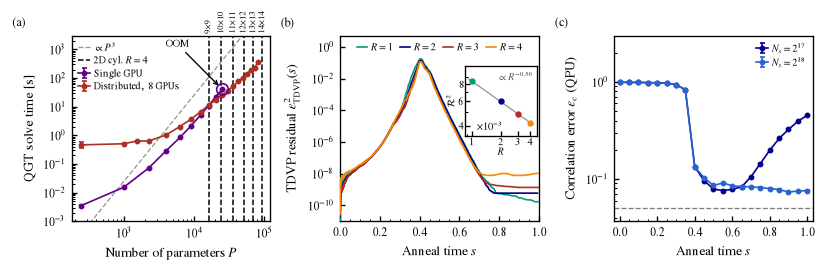

width in = 6.75


In [8]:
# Combined scaling panels
fig, axes = plt.subplots(1, 3, figsize=(COL2, COL2 * 0.32), constrained_layout=True)
PANEL_XY = (-0.30, 1.10)  # panel-letter position, axes fraction

# -- (a) QGT-inversion scaling: single GPU vs distributed (8-GPU) eigh -----------------
ax = axes[0]
COL_A = {"single": COLORBLIND[5], "sharded": COLORBLIND[2]}
LAB_A = {"single": "Single GPU", "sharded": "Distributed"}
runs_a = {k: v for k, v in load_eigh_runs().items() if k[1] in (1, 8)}
plotted_a = False
for mode, n_dev in sorted(runs_a, key=lambda k: (k[0] != "single", k[1])):
    rs = runs_a[(mode, n_dev)]
    npar = np.array([r["n_params"] for r in rs], float)
    tmed = np.array([r["t_med"] for r in rs], float)
    tstd = np.array([r["t_std"] for r in rs], float)
    ok = np.isfinite(tmed)
    color = COL_A[mode]
    lbl = LAB_A["single"] if mode == "single" else f"{LAB_A['sharded']}, {n_dev} GPUs"
    if ok.any():
        ax.errorbar(npar[ok], tmed[ok], yerr=_yerr(tstd[ok]), fmt="-o", ms=2.5,
                    lw=1.0, color=color, label=lbl, capsize=1.5)
        plotted_a = True
    else:  # benchmark for that device count not completed -> keep it in the legend
        ax.plot([], [], "-o", ms=2.5, color=color, label=f"{lbl} (pending)")

if plotted_a:
    ref_a = runs_a.get(("single", 1)) or next(iter(runs_a.values()))
    fin = [r for r in ref_a if np.isfinite(r["t_med"])]
    if fin:  # P^3 guide, anchored to the smallest finite single-GPU timing
        n0, t0 = fin[0]["n_params"], fin[0]["t_med"]
        xs = np.array([r["n_params"] for r in ref_a], float)
        ax.plot(xs, 0.1 * t0 * (xs / n0) ** 3, "--", color="0.6", lw=0.8,
                label=r"$\propto P^3$")
    ax.set_xscale("log"); ax.set_yscale("log")
    if fin:  # single-GPU OOM = its largest feasible P (last finite-time point)
        P_oom, t_oom = fin[-1]["n_params"], fin[-1]["t_med"]
        ax.plot(P_oom, t_oom, "o", mfc="none", mec=COL_A["single"], ms=7, mew=1.0,
                zorder=5)
        ax.annotate("OOM", xy=(P_oom, t_oom), xycoords="data", xytext=(-20, 24),
                    textcoords="offset points", color="black", fontsize=FS_SMALL,
                    ha="right", va="bottom",
                    arrowprops=dict(arrowstyle="->", color="black", lw=0.8,
                                    shrinkA=0, shrinkB=3))
        print(f"(a) single-GPU OOM point: P={int(P_oom)}, t_med={t_oom:.2f}s")

    CYL_ORDERS, CYL_RANK, CYL_LS = [2, 4], 4, [9, 10, 11, 12, 13, 14]
    for j, L in enumerate(CYL_LS):
        N = L * L
        n_upper = N * (N - 1) // 2
        P = n_upper * sum(1 if k == 2 else CYL_RANK for k in CYL_ORDERS)
        ax.axvline(P, color="black", lw=0.9, ls="--", zorder=1,
                   label=(r"2D cyl. $R{=}4$" if j == 0 else "_nolegend_"))
        ax.annotate(rf"${L}{{\times}}{L}$", xy=(P, 1.002),
                    xycoords=("data", "axes fraction"), xytext=(0,1.),
                    textcoords="offset points", rotation=90, fontsize=5,
                    color="black", ha="center", va="bottom")
  
        print(f"(a) 2D cylinder R=4 L={L} (N={N}): P={P} (legacy_rank_k2=False)")
    ax.legend(frameon=False, fontsize=FS_SMALL, loc="upper left", handlelength=1.2,
              handletextpad=0.4, labelspacing=0.25, borderaxespad=0.2)
else:
    ax.text(0.5, 0.5, "pending: run\nbenchmark_eigh.py", ha="center", va="center",
            transform=ax.transAxes, color="0.5")
    print("(a) data/eigh/: no benchmark results found yet")
ax.set_ylim(1e-3, 3e3)
ax.set_xlabel(r"Number of parameters $P$")
ax.set_ylabel("QGT solve time [s]")
ax.text(*PANEL_XY, "(a)", transform=ax.transAxes, ha="left", va="top",
        fontsize=FS_TICK)

# -- (b) where the residual lives: eps^2(s) vs ansatz rank ----------------------------
ax = axes[1]
RUN_B = dict(experiment="final_20", topology="2d", shape="8x8", instance=0, t_a=20)
dirs_b = _run_dirs(**RUN_B)
traj = {}
for rk in RANKS:
    log = load_log(dirs_b[rk]) if rk in dirs_b else None
    if log is None or f"{STAGE}/epsilon_squared" not in log:
        continue
    s_, eps_, r2_ = _eps2_trajectory(log)
    traj[rk] = dict(s=s_, eps=eps_, r2=r2_)
if traj:
    for rk in sorted(traj):
        ax.plot(traj[rk]["s"], _rolling_median(traj[rk]["eps"]), color=rank_col[rk],
                lw=1.0, label=f"$R={rk}$", zorder=3)
    ax.set_yscale("log"); ax.set_xlim(0, 1); ax.set_ylim(1e-11, 5.0)
    ax.legend(fontsize=FS_SMALL, loc="upper center", ncol=len(traj), handlelength=1.0,
              handletextpad=0.4, columnspacing=0.7, borderaxespad=0.3)
    # inset: anneal-averaged residual <R^2> = sum_i eps_i^2 dt_i / sum_i dt_i vs rank,
    # log-log so the power law <R^2> ~ R^beta is a straight line
    axin = ax.inset_axes([0.63, 0.46, 0.36, 0.38])
    rs_b = np.array(sorted(traj), float)
    r2s = np.array([traj[r]["r2"] for r in sorted(traj)])
    if len(rs_b) >= 2:
        beta, ic = np.polyfit(np.log10(rs_b), np.log10(r2s), 1)
        xg = np.array([rs_b[0] * 0.93, rs_b[-1] * 1.07])
        axin.plot(xg, 10 ** (beta * np.log10(xg) + ic), "-", color="0.6", lw=0.8,
                  zorder=1)
        axin.text(0.95, 0.92, rf"$\propto R^{{{beta:.2f}}}$", transform=axin.transAxes,
                  ha="right", va="top", fontsize=FS_SMALL, color="0.35")
    for rk in sorted(traj):
        axin.plot(rk, traj[rk]["r2"], "o", ms=2.8, color=rank_col[rk], zorder=3)
    axin.set_xscale("log"); axin.set_yscale("log")
    axin.set_xlim(0.86, 4.7); axin.set_ylim(0.8 * r2s.min(), 1.3 * r2s.max())
    _log_ticks(axin, "x", list(sorted(traj)))
    _log_ticks(axin, "y", [4e-3, 6e-3, 8e-3], ["4", "6", "8"])
    axin.tick_params(labelsize=FS_SMALL, pad=1.0)
    axin.set_xlabel(r"$R$", fontsize=FS_SMALL, labelpad=0)
    axin.set_ylabel(r"$\mathcal{R}^2$", fontsize=FS_SMALL, labelpad=1)
    # the 1e-3 tick prefix goes bottom-left: <R^2>(R) falls left-to-right, so that
    # corner is the empty one (it sits top-left in the single-column version)
    axin.text(0.16, 0.05, r"$\times 10^{-3}$", transform=axin.transAxes, ha="left",
              va="bottom", fontsize=FS_SMALL)
    for rk in sorted(traj):
        print(f"(b) R={rk}  <R^2>={traj[rk]['r2']:.4e}  n_steps={len(traj[rk]['eps'])}")
    if len(rs_b) >= 2:
        print(f"(b) rank exponent beta = {beta:.3f}  (<R^2> ~ R^beta)")
else:
    ax.text(0.5, 0.5, "pending: no logs for\n" + str(RUN_B), ha="center", va="center",
            transform=ax.transAxes, color="0.5")
    print("(b) no runs found under", os.path.join(DATA_DIR, "tvmc", RUN_B["experiment"]))
ax.set_xlabel(r"Anneal time $s$")
ax.set_ylabel(r"TDVP residual $\epsilon^2_{\mathrm{TDVP}}(s)$")
ax.text(*PANEL_XY, "(b)", transform=ax.transAxes, ha="left", va="top",
        fontsize=FS_TICK)

# -- (c) correlation error over the anneal vs training sample count -------------------

ax = axes[2]
CREF = "qpu"                       # reference correlations for eps_c in this panel
ns_runs = {int(cfg["n_samples"]): sp for cfg, sp in find_paper_run("biclique_ns")}
# low -> high N_s reads as a bad -> good ramp
_ns_palette = ["#00008C", "#2A62D0","#71C4E8"]
ns_col = {ns: _ns_palette[i % len(_ns_palette)] for i, ns in enumerate(sorted(ns_runs))}


def _eps_c_vs_s(save_path):
    """(s, eps_mps, eps_mps_std, eps_qpu, eps_qpu_std, n_eval) over every snapshot.

    One point per s from the corrs_n*_t{s}.npz files in a run folder, using the
    largest evaluation N_s present at that s (same rule as best_corr_error)."""
    best = {}
    for f in glob.glob(os.path.join(save_path, "corrs_n*_t*.npz")):
        m = re.search(r"corrs_n(\d+)_t([\d.]+)\.npz", os.path.basename(f))
        if not m:
            continue
        n, s_ = int(m.group(1)), float(m.group(2))
        if s_ not in best or n > best[s_][0]:
            best[s_] = (n, f)
    ss = np.array(sorted(best), float)
    cols = np.array([load_corr_errors(best[s_][1]) for s_ in ss]).reshape(len(ss), 4)
    n_eval = sorted({n for n, _ in best.values()})
    return (ss, cols[:, 0], cols[:, 1], cols[:, 2], cols[:, 3], n_eval)


def _ns_label(ns):
    """'$N_s = 2^{17}$' for powers of two, plain integers otherwise."""
    p = int(round(np.log2(ns)))
    return rf"$N_s = 2^{{{p}}}$" if 2 ** p == ns else rf"$N_s = {ns}$"


final_c, eps_all, plotted_c = {}, [], False
for ns in sorted(ns_runs):
    if ns>300000:
        continue
    s_, em, em_s, eq, eq_s, n_eval = _eps_c_vs_s(ns_runs[ns])
    if s_.size == 0:
        print(f"(c) N_s={ns}: pending, no corrs_n*_t*.npz in {ns_runs[ns]}")
        ax.plot([], [], "-o", color=ns_col[ns], label=_ns_label(ns) + " (pending)")
        continue
    # QPU reference where it exists, MPS wherever the QPU one is missing
    e, e_s = (eq, eq_s) if CREF == "qpu" else (em, em_s)
    fb = ~np.isfinite(e) & np.isfinite(em if CREF == "qpu" else eq)
    if fb.any():
        alt, alt_s = (em, em_s) if CREF == "qpu" else (eq, eq_s)
        e, e_s = np.where(fb, alt, e), np.where(fb, alt_s, e_s)
        print(f"(c) N_s={ns}: {fb.sum()}/{fb.size} snapshots fell back to the "
              f"{'MPS' if CREF == 'qpu' else 'QPU'} reference")
    ok = np.isfinite(e)
    if not ok.any():
        print(f"(c) N_s={ns}: corrs present but no finite {CREF.upper()} eps_c")
        continue
    ax.errorbar(s_[ok], e[ok], yerr=_yerr(e_s[ok]), fmt="-o", ms=2.5, lw=1.0,
                color=ns_col[ns], label=_ns_label(ns), capsize=1.5, zorder=3)
    plotted_c = True
    eps_all.append(e[ok])
    final_c[ns] = (e[ok][-1], e_s[ok][-1], s_[ok][-1])
    print(f"(c) N_s={ns:>7d}  {ok.sum():>2d} snapshots  s in [{s_[ok][0]:.2f}, "
          f"{s_[ok][-1]:.2f}]  eps_c(s_max)={e[ok][-1]:.4f} +/- {e_s[ok][-1]:.4f}"
          f"  eval N_s={n_eval}")

ax.axhline(REF, color="0.5", ls="--", lw=0.8)
ax.set_yscale("log"); ax.set_xlim(-0.03, 1.03)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())  # majors only
ax.set_xlabel(r"Anneal time $s$")
ax.set_ylabel(r"Correlation error $\epsilon_c$ (QPU)")
ax.legend(frameon=False, fontsize=FS_SMALL, loc="upper right", handlelength=1.2,
          handletextpad=0.4, labelspacing=0.25, borderaxespad=0.3)
if plotted_c:
    all_e = np.concatenate(eps_all)
    ax.set_ylim(0.5 * np.nanmin(all_e), 3.0 * np.nanmax(all_e))
    
else:
    ax.text(0.5, 0.5, "pending: run\ndisbatch_corrs.sh biclique_ns", ha="center",
            va="center", transform=ax.transAxes, color="0.5", fontsize=FS_SMALL)
    ax.set_ylim(1e-3, 1.0)
    print("(c) no biclique_ns correlations on disk yet;",
          f"{len(ns_runs)} run folder(s) found")
ax.text(*PANEL_XY, "(c)", transform=ax.transAxes, ha="left", va="top",
        fontsize=FS_TICK)


fig.get_layout_engine().set(w_pad=0.03, wspace=0.03)
fig.savefig(f"{FIGDIR}/fig_combined_scaling.pdf")
plt.show()
print("width in =", fig.get_size_inches()[0])

## Largest run: diamond $8\times8\times8$ ($N=128$) diagnostics

Every per-step diagnostic logged by the single largest production run — `large_diamond`
(diamond $8{\times}8{\times}8$, $N=128$ spins, rank $R=1$, $t_a=7$ ns, $N_s=2^{17}$,
parallel tempering with 16 replicas) — in one $3{\times}3$ block, all against the anneal time $s$ and, where a
quantity is resolved per RK45 stage, for stage 0:

- **(a)** the stage-0 TDVP residual $\epsilon^2$ with its $dt$-weighted mean $\langle\mathcal{R}^2\rangle$,
  **(b)** its cumulative integral $\int_0^s\epsilon^2\,ds'$ (where the residual budget is spent),
  **(c)** the adaptive RK45 step $\Delta s$ between the controller's `dt_min`/`dt_max`;
- **(d)** the generator inter-chain $\hat R$, **(e)** the blurred-sampling ESS,
  **(f)** the parallel-tempering acceptance of all 16 $\beta_i$ (hot$\to$cold), hot and cold ends labelled;
- **(g)** the median force SNR against the `snr_atol` filter floor and **(h)** the median
  $S$-eigenbasis SNR (log keys `snrF_med` and `snr_med`), **(i)** the total cumulative wall time.

The run is still integrating, so the curves stop at whatever $s$ is on disk; re-running the cell
after it finishes just extends them.

/tmp/ipykernel_1550686/4125198740.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=FS_SMALL, loc="upper left",


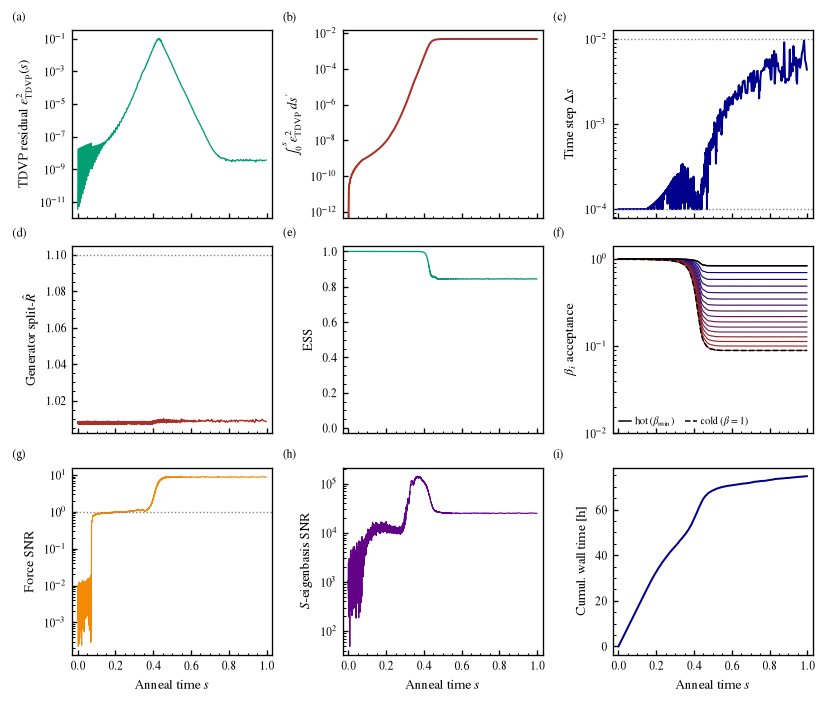

large_diamond  diamond 8x8x8  N=128  R=1  t_a=7 ns  N_s=131072  PT x16
  ./data/tvmc/large_diamond/diamond_8x8x8/instance_0/t_a_7/jastrow_o24_snr1/pt_r16_ns_131072_nc_2048_sw_512/q0.3/rk45_dt_min1.00e-04_dt_max1.00e-02/24d83d44
  3914 steps logged, s_max = 0.998  (still integrating)   coverage(finite eps^2) = 1.000
  <R^2> (dt-weighted) = 4.270e-03      int eps^2 ds = 4.692e-03
  R_hat: final 1.008, max 1.010   ESS: median 1.000, min 0.842
  PT acceptance at s_max: hot 0.834, cold 0.089   (ladder median 0.235)
  stage 0 SNR medians over the anneal: force 0.97, S-eigenbasis 1.18e+04   steps with force SNR < snr_atol=1: 59.4%
  wall time   74:41:21 (74.7 h) -- MCMC 8%  QGT 8%  Solve 82%  Blur 0%
  eps_c: no corrs_n*_t1.000.npz yet (0 corrs file(s) on disk) -- run disbatch_corrs.sh large_diamond
width in = 6.75


In [17]:
# --- largest run: per-step diagnostics for large_diamond (diamond 8x8x8, N=128) -----
# One production run, still integrating, so every panel plots the prefix of the anneal
# that is on disk; re-running the cell after the job finishes just extends the curves.
# Log-key map: the S-eigenbasis SNR ("snrS") is logged as `snr_med`, the parameter-basis
# force SNR as `snrF_med` (src/tdvp_utils.py). RK45 logs 7 stages, `0/...` .. `6/...`;
# every stage-resolved panel below shows stage STAGE, the notebook-wide convention.
from matplotlib.colors import LinearSegmentedColormap

# beta ramp navy->red for the PT ladder
ld_beta_cmap = LinearSegmentedColormap.from_list("beta", [COLORBLIND[1], COLORBLIND[2]])

ld_runs = find_paper_run("large_diamond")
ld_cfg, ld_path = ld_runs[0] if ld_runs else (None, None)
ld_log = None
if ld_path is None:
    print("large_diamond: no config under configs/large_diamond/")
elif not os.path.exists(os.path.join(ld_path, "log.json")):
    print(f"large_diamond: pending, no log.json at {ld_path}")
else:
    try:
        ld_log = load_log(ld_path)
    except json.JSONDecodeError:   # the job is live; a torn write is possible
        print("large_diamond: log.json is mid-write, re-run this cell")

if ld_log is not None:
    def _ld(key):
        """(s, values) for a top-level log key of this run."""
        it, v = series(ld_log, key)
        return to_s(ld_log, it), v

    def _ld_eps_dt(stage=STAGE):
        """(s, eps^2, dt) for one RK45 stage, aligned on iters.

        eps^2 and dt are History series on a shared iters(=s) axis whose lengths
        differ by one (dt carries the extra s=0 pre-step point), so they are joined
        on iters rather than zipped -- same alignment as _tdvp_residual above."""
        ie, eps = series(ld_log, f"{stage}/epsilon_squared")
        idt, dt = series(ld_log, "dt")
        dt_by_it = dict(zip(idt, dt))
        w = np.array([dt_by_it.get(i, 0.0) for i in ie])
        return to_s(ld_log, ie), eps, w

    fig, axes = plt.subplots(3, 3, figsize=(COL2, COL2 * 0.85),
                             constrained_layout=True, sharex=True)
    LD_PANEL_XY = (-0.30, 1.10)    # panel-letter position, axes fraction

    # -- (a) TDVP residual eps^2 over the anneal (stage STAGE) ------------------------
    ax = axes[0, 0]
    s_e, eps2, w_e = _ld_eps_dt()
    ld_fin = np.isfinite(eps2) & (w_e > 0)
    ld_r2 = (float(np.sum(eps2[ld_fin] * w_e[ld_fin]) / w_e[ld_fin].sum())
             if ld_fin.any() else np.nan)
    ax.plot(s_e, eps2, "-", color=COLORBLIND[0], lw=0.8)
    ax.set_yscale("log")
    ax.set_ylabel(r"TDVP residual $\epsilon^2_{\mathrm{TDVP}}(s)$")
    ax.legend(frameon=False, fontsize=FS_SMALL, loc="upper left",
              handlelength=1.2, handletextpad=0.4, borderaxespad=0.2)

    # -- (b) cumulative residual: where the eps^2 budget is spent ---------------------
    ax = axes[0, 1]
    ld_cum_eps = np.cumsum(np.where(np.isfinite(eps2), eps2, 0.0) * w_e)
    ax.plot(s_e, ld_cum_eps, "-", color=COLORBLIND[2])
    ax.set_yscale("log")
    if ld_cum_eps[-1] > 0:  # the first decades are pre-gap noise; keep the plateau
        ax.set_ylim(1e-10 * ld_cum_eps[-1], 3 * ld_cum_eps[-1])
    ax.set_ylabel(r"$\int_0^s \epsilon^2_{\mathrm{TDVP}}\,ds'$")

    # -- (c) adaptive RK45 step, against the controller's dt_min/dt_max bounds --------
    ax = axes[0, 2]
    s_dt, dt_v = _ld("dt")
    ax.plot(s_dt, dt_v, "-", color=COLORBLIND[1])
    for bound in (ld_cfg["dt_min"], ld_cfg["dt_max"]):
        ax.axhline(bound, color="0.5", ls=":", lw=0.8)
    ax.set_yscale("log")
    ax.set_ylabel(r"Time step $\Delta s$")

    # -- (d) generator inter-chain R_hat ---------------------------------------------
    ax = axes[1, 0]
    it_r, r_hat = generator_field(ld_log, "R_hat")
    s_r = to_s(ld_log, it_r)
    ax.plot(s_r, r_hat, "-", color=COLORBLIND[2], lw=0.8)
    ax.axhline(1.1, color="0.5", ls=":", lw=0.8)
    ax.set_ylabel(r"Generator split-$\hat{R}$")

    # -- (e) blurred-sampling ESS (stage STAGE) --------------------------------------
    ax = axes[1, 1]
    s_ess, ess = _ld(f"{STAGE}/ess_blurred")
    ax.plot(s_ess, ess, "-", color=COLORBLIND[0], lw=0.8)
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel("ESS")

    # -- (f) parallel-tempering per-beta acceptance ----------------------------------
    # 16 replicas hot->cold; a colorbar here would narrow the column and break the
    # shared-x alignment with the rows above, so the two ends are labelled instead.
    ax = axes[1, 2]
    e = ld_log["pt_accept_per_beta"]
    M = np.asarray(e["value"], float)               # (n_steps, n_replicas), hot->cold
    s_pt = to_s(ld_log, np.asarray(e["iters"], float))
    for j, c in enumerate(ld_beta_cmap(np.linspace(0, 1, M.shape[1]))):
        ax.plot(s_pt, M[:, j], "-", color=c, lw=0.7)
    s_h, acc_h = _ld("pt_accept_hot")
    s_c, acc_c = _ld("pt_accept_cold")
    ax.plot(s_h, acc_h, "-", color="k", lw=0.9, label=r"hot ($\beta_{\min}$)")
    ax.plot(s_c, acc_c, "--", color="k", lw=0.9, label=r"cold ($\beta=1$)")
    ax.set_yscale("log")
    ax.set_ylim(1e-2, 1.4)
    ax.set_ylabel(r"$\beta_i$ acceptance")
    ax.legend(frameon=False, fontsize=FS_SMALL, loc="lower left", ncol=2,
              handlelength=1.2, handletextpad=0.4, columnspacing=1.0,
              borderaxespad=0.2)

    # -- (g) median force SNR, stage STAGE -------------------------------------------
    ax = axes[2, 0]
    ld_snr_atol = float(ld_cfg.get("snr_atol") or 0.0)  # Schmitt force-SNR filter floor
    s_snrf, snrF0 = _ld(f"{STAGE}/snrF_med")
    ax.plot(s_snrf, snrF0, "-", color=COLORBLIND[3], lw=0.7)
    if ld_snr_atol > 0:
        ax.axhline(ld_snr_atol, color="0.5", ls=":", lw=0.8)
    ax.set_yscale("log")
    ax.set_ylabel(r"Force SNR")

    # -- (h) median S-eigenbasis SNR, stage STAGE ------------------------------------
    ax = axes[2, 1]
    s_snrs, snrS0 = _ld(f"{STAGE}/snr_med")
    ax.plot(s_snrs, snrS0, "-", color=COLORBLIND[5], lw=0.7)
    ax.set_yscale("log")
    ax.set_ylabel(r"$S$-eigenbasis SNR")

    # -- (i) cumulative wall time ----------------------------------------------------
    # only the total is drawn; the per-component split is reported in the summary below
    ax = axes[2, 2]
    LD_TIME = [("time/total", "Total"), ("time/mcmc", "MCMC"), ("time/qgt", "QGT"),
               ("time/solve", "Solve"), ("time/blur", "Blur")]
    ld_hours = {lab: np.sum(_ld(key)[1]) / 3600.0
                for key, lab in LD_TIME if key in ld_log}
    s_t, t_v = _ld("time/total")
    ax.plot(s_t, np.cumsum(t_v) / 3600.0, "-", color=COLORBLIND[1])
    ax.set_ylabel("Cumul. wall time [h]")

    for i, ax in enumerate(axes.ravel()):
        ax.set_xlim(-0.03, 1.03)
        ax.set_xticks(np.arange(0, 1.01, 0.2))
        ax.text(*LD_PANEL_XY, f"({'abcdefghi'[i]})", transform=ax.transAxes,
                ha="left", va="top", fontsize=FS_TICK)
    for ax in axes[2, :]:
        ax.set_xlabel(r"Anneal time $s$")

    fig.get_layout_engine().set(w_pad=0.03, h_pad=0.03, wspace=0.03, hspace=0.03)
    fig.savefig(f"{FIGDIR}/fig_large_diamond_diagnostics.pdf")
    plt.show()

    # ---- run summary ---------------------------------------------------------------
    s_max = float(series(ld_log, "t")[1][-1])
    N_ld = _nsites_shape(ld_path)
    if not np.isfinite(N_ld):   # no corrs file yet -> N off the instance edge list
        from src.utils import n_sites_from_instance
        N_ld = n_sites_from_instance(ld_cfg["instance_dir"], ld_cfg["topology"],
                                     ld_cfg["shape"], ld_cfg["instance"],
                                     ld_cfg["precision"])
    print(f"large_diamond  {ld_cfg['topology']} "
          f"{'x'.join(map(str, ld_cfg['shape']))}  N={N_ld:.0f}  R={ld_cfg['rank']}"
          f"  t_a={ld_cfg['t_a']:g} ns  N_s={ld_cfg['n_samples']}"
          f"  PT x{ld_cfg['pt_n_replicas']}")
    print(f"  {ld_path}")
    print(f"  {len(s_e)} steps logged, s_max = {s_max:.3f}  "
          f"({'anneal complete' if s_max > 0.999 else 'still integrating'})"
          f"   coverage(finite eps^2) = {w_e[ld_fin].sum() / w_e.sum():.3f}")
    print(f"  <R^2> (dt-weighted) = {ld_r2:.3e}      int eps^2 ds = {ld_cum_eps[-1]:.3e}")
    print(f"  R_hat: final {r_hat[-1]:.3f}, max {np.nanmax(r_hat):.3f}"
          f"   ESS: median {np.nanmedian(ess):.3f}, min {np.nanmin(ess):.3f}")
    print(f"  PT acceptance at s_max: hot {acc_h[-1]:.3f}, cold {acc_c[-1]:.3f}"
          f"   (ladder median {np.median(M[-1]):.3f})")
    print(f"  stage {STAGE} SNR medians over the anneal: force {np.nanmedian(snrF0):.2f}, "
          f"S-eigenbasis {np.nanmedian(snrS0):.2e}"
          f"   steps with force SNR < snr_atol={ld_snr_atol:g}: "
          f"{100 * np.mean(snrF0 < ld_snr_atol):.1f}%")
    if "Total" in ld_hours:
        tot_s = ld_hours["Total"] * 3600.0
        split = "  ".join(f"{lab} {100 * h / ld_hours['Total']:.0f}%"
                          for lab, h in ld_hours.items() if lab != "Total")
        print(f"  wall time {_hms(tot_s)} ({ld_hours['Total']:.1f} h) -- {split}")
    cf = corr_files(ld_path, S)
    if cf:
        e_, es_ = best_corr_error(ld_path, S, with_err=True)
        print(f"  eps_c(s={S:g}) = {e_:.4f} +/- {es_:.4f}  (eval N_s={max(cf)})")
    else:
        n_any = len(glob.glob(os.path.join(ld_path, "corrs_n*_t*.npz")))
        print(f"  eps_c: no corrs_n*_t{S:1.3f}.npz yet ({n_any} corrs file(s) on disk)"
              " -- run disbatch_corrs.sh large_diamond")
    print("width in =", fig.get_size_inches()[0])